In [1]:
import numpy as np

conf_matrix = np.array([[142105, 8847],
                        [4708, 3888]], dtype=float)

negative_rate = np.array([[92.6, 78.6],
                          [11.6, 1.9]]) / 100

actual_negative = conf_matrix * negative_rate
actual_positive = conf_matrix * (1 - negative_rate)

true_conf_matrix = np.array([
    [actual_negative[0,0] + actual_negative[1,0],  # TN
     actual_negative[0,1] + actual_negative[1,1]], # FP
    [actual_positive[0,0] + actual_positive[1,0],  # FN
     actual_positive[0,1] + actual_positive[1,1]]  # TP
])

TN, FP, FN, TP = conf_matrix.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print("CM")
print(np.round(conf_matrix).astype(int))
print("CM(estimated)")
print(np.round(true_conf_matrix).astype(int))

print("score")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

TN, FP, FN, TP = true_conf_matrix.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print("score(estimated)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Positive = TP + FN
Negative = FP + TN
Positive_rate = Positive/(Positive + Negative)
print(f"positive rate：{Positive_rate}")


CM
[[142105   8847]
 [  4708   3888]]
CM(estimated)
[[132135   7028]
 [ 14678   5707]]
score
Precision : 0.3053
Recall    : 0.4523
F1-score  : 0.3645
score(estimated)
Precision : 0.4482
Recall    : 0.2800
F1-score  : 0.3446
positive rate：0.12776736781407486


,ID,bacteria_share_pct
0,DRR000001,99.999910
1,DRR000002,99.999018
2,DRR000003,0.015484
3,DRR000004,0.014661
4,DRR000005,0.000000
...,...,...
34967273,SRR9999995,0.000000
34967274,SRR9999996,1.382690
34967275,SRR9999997,1.583985
34967276,SRR9999998,1.597032


,ID,cm
0,ERR348568,TN
1,SRR7419921,TN
2,SRR3901710,TN
3,SRR3901721,TN
4,SRR3901724,TN
...,...,...
159543,SRR7504988,TN
159544,SRR7504990,TN
159545,SRR7504992,TN
159546,SRR7504993,TN


,ID,bacteria_share_pct,cm
0,DRR001894,0.083802,TN
1,DRR001895,0.065157,TN
2,DRR002384,0.066993,TN
3,DRR002385,0.050380,TN
4,DRR018832,0.385283,FP
...,...,...,...
157801,SRR9995114,0.012974,TN
157802,SRR9995115,0.024670,TN
157803,SRR9995116,0.014242,TN
157804,SRR9995117,0.017169,TN


/var/folders/yp/r6xbj_r95tn65ds3frrphyp00000gn/T/ipykernel_26060/4025817110.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


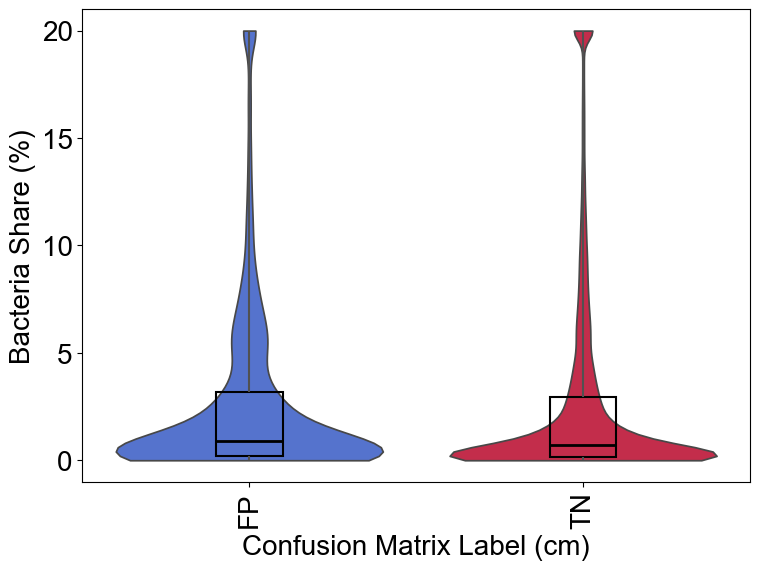

Wilcoxon Rank-Sum Test (TN vs FP)
TN - Mean: 3.305, Median: 0.718
FP - Mean: 3.062, Median: 0.894
Statistic U = 300919803.000, p-value = 0.0000
=> There is a statistically significant difference between the TN and FP groups.


In [13]:
!pip install scikit-posthocs
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 20
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

dir_name = "bacteria_analysis"
if not os.path.exists(dir_name):
    os.makedirs(dir_name)

# Load data
bacteria_file = "All_STAT_bacteria_pct.txt"
bacteria_info = pd.read_csv(bacteria_file, sep="\t")
bacteria_data = bacteria_info[["acc", "bacteria_share_pct"]].rename(columns={"acc": "ID"})
display(bacteria_data)

# Load and concat prediction data
folder_name = "0909"
label_dfs = []
for n in range(5):
    df = pd.read_csv(f"./{folder_name}/Infection_Prediction_Stacking_{n}.csv")
    df = df[["ID", "Infection", "Prediction_Label"]].copy()
    
    df["cm"] = df.apply(
        lambda x: (
            "TN" if x["Infection"] == "Negative" and x["Prediction_Label"] == "Negative" else
            "FP" if x["Infection"] == "Negative" and x["Prediction_Label"] == "Positive" else
            "FN" if x["Infection"] == "Positive" and x["Prediction_Label"] == "Negative" else
            "TP"
        ),
        axis=1
    )

    label_dfs.append(df[["ID", "cm"]])

label_data = pd.concat(label_dfs, ignore_index=True)
display(label_data)

merged_data = pd.merge(bacteria_data, label_data, on="ID", how="inner")

cm_order = ["TP", "FN", "TN", "FP"]
merged_data["cm"] = pd.Categorical(merged_data["cm"], categories=cm_order, ordered=True)
display(merged_data)

threshold = 20
merged_data["bacteria_share_pct_clip"] = merged_data["bacteria_share_pct"].clip(upper=threshold)

# plot
plt.figure(figsize=(8, 6))
df = merged_data[merged_data["cm"].isin(["FP", "TN"])].copy()
df["cm"] = df["cm"].astype(str)
custom_palette = {
    "FP": "royalblue",
    "TN": "crimson"
}
sns.violinplot(
    data=df,
    x="cm",
    y="bacteria_share_pct_clip",
    order=["FP","TN"],
    palette=custom_palette,
    cut=0,
    inner=None
)
sns.boxplot(
    data=df,
    x="cm",
    y="bacteria_share_pct_clip",
    order=["FP","TN"],
    whis=[0, 100],
    width=0.2,
    showcaps=False,
    boxprops={'facecolor': 'none', "edgecolor": "black", "linewidth": 1.5},
    whiskerprops={'linewidth': 1.5},
    medianprops={'color': 'black', "linewidth": 2}
)
plt.xlabel("Confusion Matrix Label (cm)")
plt.ylabel("Bacteria Share (%)")
plt.grid(False)
plt.tight_layout()
plt.xticks(rotation=90)
plt.savefig(f"./{dir_name}/Bacteria_Share≤{threshold}%FP_vs_TN.pdf", bbox_inches='tight')
plt.show()


# Wilcoxon Rank-Sum Test (TN vs FP)
tn_values = merged_data.loc[merged_data["cm"] == "TN", "bacteria_share_pct"].dropna()
fp_values = merged_data.loc[merged_data["cm"] == "FP", "bacteria_share_pct"].dropna()

stat, p = stats.mannwhitneyu(tn_values, fp_values, alternative='two-sided')

print("Wilcoxon Rank-Sum Test (TN vs FP)")
print(f"TN - Mean: {tn_values.mean():.3f}, Median: {tn_values.median():.3f}")
print(f"FP - Mean: {fp_values.mean():.3f}, Median: {fp_values.median():.3f}")
print(f"Statistic U = {stat:.3f}, p-value = {p:.4f}")

if p < 0.05:
    print("=> There is a statistically significant difference between the TN and FP groups.")
else:
    print("=> There is no statistically significant difference between the TN and FP groups.")
